In [1]:
import numpy as np
from scipy.io import loadmat
from enc_func import *
import matplotlib.pyplot as plt   
import time  
from tqdm import tqdm
from offline_task import *


In [2]:

# 파라미터 생성
Ts = 0.1  # 샘플링타임 1초
env = Params()  # 환경 변수 
sk = Seret_key(env) # 비밀키

'''
스케일 정하기
'''

# 양자화 파라미터 # 10^10
# r_quant = 10000000000
# s_quant = 10000000000
r_quant = 100000
s_quant = 100000

# 1) 오프라인 행렬 계산 및 저장
offline = compute_offline_mats(env, s_quant)
save_offline_mats(offline)
print("오프라인 행렬 저장\n")



# 오프라인 행렬들 준비  #변경사항: Phi_pinv \in R 을 오프라인 행렬로 변경
# offline = np.load("offline_mats.npz", allow_pickle=True)
offline = np.load("matrices.npz", allow_pickle=True)

F_bar = offline["F_bar"]          # 24x24
G_bar = offline["G_bar"]          # 24x6
H_bar = offline["H_bar"]          # 60x24
Phi_pinv_bar = offline["Phi_pinv_bar"]
T1_all = offline["T1_all"]        # 60x23x24
T2_all = offline["T2_all"]        # 60x1x24z
V1_all = offline["V1_all"]        # 60x24x23
V2_all = offline["V2_all"]        # 60x24x1
S_xi_all = offline["S_xi_all"]    # 60x23x23
S_v_all  = offline["S_v_all"]     # 60x23x6
Psi_all  = offline["Psi_all"]     # 60x1x23
Sigma_all = offline["Sigma_all"]  # 60x1x6
Sigma_pinv_all = offline["Sigma_pinv_all"]  # 60x6x1 (dtype=object)


# Ts = 0.1, 이산화된 플랜트 A B C 행렬
A = np.array([
    [ 0.466616, 0.077317, 0.470144, 0.017938, 0.063239, 0.001325 ],
    [ -8.134824, 0.412495, 5.858792, 0.457587, 2.276032, 0.062312 ],
    [ 0.470144, 0.017938, 0.059711, 0.060703, 0.470144, 0.017938 ],
    [ 5.858792, 0.457587, -11.717584, 0.017219, 5.858792, 0.457587 ],
    [ 0.063239, 0.001325, 0.470144, 0.017938, 0.466616, 0.077317 ],
    [ 2.276032, 0.062312, 5.858792, 0.457587, -8.134824, 0.412495 ]
], dtype=np.float64)

B = np.array([ 0.437786, 7.731673, 0.048455, 1.793845, 0.002295, 0.132508 ], dtype=np.float64)  # shape (6,)

C = np.array([
    [ 1, 0, 0, 0, 0, 0 ],
    [ 0, 0, 1, 0, 0, 0 ],
    [ 0, 0, 0, 0, 1, 0 ],
    [ 1, 0, -1, 0, 0, 0 ],
    [ 0, 0, 1, 0, -1, 0 ]
], dtype=np.float64)

K = np.array([ 0.371016, -0.101849, -0.513215, -0.002060, 0.023667, -0.021206 ], dtype=np.float64)  # shape (6,)


100000
오프라인 행렬 저장



In [3]:

## 시뮬레이션 세팅

iter = 100
n_channels = 60 # j_index
execution_times = []  # 실행 시간을 저장할 리스트


'''
# 초기값
'''
xp0 = np.array([[1], [1], [1], [1], [1], [1]])          # 플랜트 초기값
# z_hat0 = np.full((24, 1), 0.1, dtype=float)                         # z_hat 초기값
z_hat0 = np.full((24, 1), 0.0, dtype=float)   


# 플롯 저장용
attack_arr = np.zeros(iter)   # 각 k에서 주입한 공격 신호 저장
attack_start = iter // 2      # 절반 시점부터 공격 시작
xp = [xp0]
u = []
y = []
x_hat_list = []

# residue: 각 채널 r_j(k)의 실수 복원값을 저장: (iter, 60)
residue = np.zeros((iter, n_channels))

# 옵저버 초기 값
z_hat_bar = np.round(z_hat0 * r_quant * s_quant).astype(int)

# j 인덱스 state
Z_hat_list = []   # 길이 60, 각 원소는 24 x (N+2)
b_xi_list = []    # 길이 60, 각 원소는 23 x 1

for j in range(n_channels):
    T1_j = T1_all[j]           # 23x24
    T2_j = T2_all[j]           # 1x24
    V2_j = V2_all[j]           # 24x1
    Z_hat_j, b_xi_j = Enc_state(z_hat_bar, sk, env, T1_j, T2_j, V2_j)
    Z_hat_list.append(Z_hat_j)  # 초기값
    b_xi_list.append(b_xi_j)    # 초기값


Z_hat_ref0 = Z_hat_list[0]                        # j=0 채널 하나 사용
X_hat_cipher0 = Mod(Phi_pinv_bar @ Z_hat_ref0, env.q)
x_hat_int0 = Dec(X_hat_cipher0, sk, env)
x_hat0 = x_hat_int0 / (r_quant * s_quant * s_quant * env.L)

x_hat_list = [x_hat0]  # 이제 x_hat_list[0] = x_hat(0)


In [4]:

#  Simulation loop

for k in tqdm(range(iter)):
    # ==== 시간 측정 시작 ====
    t_start = time.perf_counter()

    # 1) 플랜트 출력 y_k = C x_k
    y_k = C @ xp[-1]          # 5x1, float64
    y.append(y_k)

    # 2) 피드백 제어 입력 u_k = K x_k
    u_k = float(K @ xp[-1])   # 스칼라
    u.append(u_k)

    # 3) v = [u; y] (6x1, float)
    v = np.vstack([
        np.array([[u_k]]),  # 1x1
        y_k                 # 5x1
    ])

    # 공격신호 
    '''
    추후 공격 신호에 변화...?
    '''
    if k >= attack_start:
        crit = (k-attack_start)/iter 
        if 0.1> crit :
            attack  = 1
        elif 0.4>crit >= 0.35:
            attack = -1
        else:
            attack = 0
    else:
        attack = 0.0
    
    attack_vector = np.zeros((6, 1), dtype=float)
    
    # 3번 센서
    attack_vector[3, 0] = attack  
    attack_arr[k] = attack        
    
    # # 공격 신호 넣기 # 실수 위에서 넣는 것으로 변경
    v += attack_vector   # 3번째 센서에만 공격

    # 인덱스 별 r_j, Z_hat_j, 동적 마스킹 파트 업데이트
    for j in range(n_channels):

        # 오프라인 행렬
        H_j = H_bar[j, :].reshape(1, 24)              # 1x24
        S_xi_j = S_xi_all[j]                          # 23x23
        S_v_j  = S_v_all[j]                           # 23x6
        Psi_j  = Psi_all[j]                           # 1x23
        Sigma_j = Sigma_all[j]                        # 1x6
        Sigma_pinv_j = Sigma_pinv_all[j]              # 6x1

        Z_hat_j = Z_hat_list[j]                       # 24 x (N+2)
        b_xi_j  = b_xi_list[j]                        # 23 x 1

        # residue R_j = H_j @ Z_hat_j (1 x (N+2))
        R_j = Mod(H_j @ Z_hat_j, env.q)           # 1 x (N+2)

        # 첫 번째 항만 잔차로 사용 (스칼라, mod q 정수로 정리)
        bbr_j = Mod(R_j[0, 0], env.q)              # Python int, mod q

        # L^-1 곱셈
        r_bar_j = Mod(bbr_j * env.invL, env.q)          
        r_j = float(r_bar_j) / (r_quant * s_quant * s_quant)

        # 실수 residue
        residue[k, j] = r_j
        
        # 출력 암호화 # 기존과 다르게 큰 수를 다루기 위해서 np.vectorize(lambda x: int(round(x)), otypes=[object])(v_scaled) 이런 꼴의 코드가 추가...
        v_scaled = v * r_quant
        v_bar = np.vectorize(lambda x: int(round(x)), otypes=[object])(v_scaled)
        V_j, b_v_j = Enc_t(v_bar, sk, b_xi_j, Sigma_pinv_j, Sigma_j, Psi_j, env)


        # 암호화된 옵저버 상태 업데이트: Z_hat_{k+1}^j
        Z_hat_j_next = Mod(F_bar @ Z_hat_j + G_bar @ V_j, env.q)

        '''
        수정된 암호스킴의 업데이트
        '''
        # (e) 마스킹 상태 업데이트: b_xi_{k+1}^j = S_xi_j b_xi_j + S_v_j b_v_j
        b_xi_j_next = S_xi_j @ b_xi_j + S_v_j @ b_v_j
        b_xi_j_next = Mod(b_xi_j_next, env.q)

        # 리스트 저장
        Z_hat_list[j] = Z_hat_j_next
        b_xi_list[j]  = b_xi_j_next

    # 5-1) z(t) \in 24x1 로 상태 추정
    # Phi_pinv_bar  : 6 x 24  -> X_hat_cipher : 6 x (N+2)
    Z_hat_ref = Z_hat_list[0]  # 하나 가져오기 (Z_hat은 마스킹 파트만 다르고 메세지는 같음)
    X_hat_cipher = Mod(Phi_pinv_bar @ Z_hat_ref, env.q)  # 6 x (N+2)

    # 복호화
    x_hat_int = Dec(X_hat_cipher, sk, env)
    x_hat_list.append(x_hat_int/ (r_quant * s_quant * s_quant * env.L))

    # 6) 플랜트 상태 업데이트: x_{k+1} = A x_k + B u_k
    xp_next = A @ xp[-1] + B.reshape(-1, 1) * u_k   # B: (6,) -> (6,1)
    xp.append(xp_next)

    # ==== 시간 측정 끝 ====
    t_end = time.perf_counter()
    execution_times.append(t_end - t_start)



'''
루프 실행 시간 통계, N = 2000일 때, 루프 당 평균 약 3초 / j 하나 당 루프 시간 0.05초
'''
execution_times = np.array(execution_times)
print(f"Iteration time min  : {execution_times.min():.6f} s")
print(f"Iteration time max  : {execution_times.max():.6f} s")
print(f"Iteration time mean : {execution_times.mean():.6f} s")

  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_24172\3366385049.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_k = float(K @ xp[-1])   # 스칼라
  4%|▍         | 4/100 [00:42<16:48, 10.50s/it]


KeyboardInterrupt: 

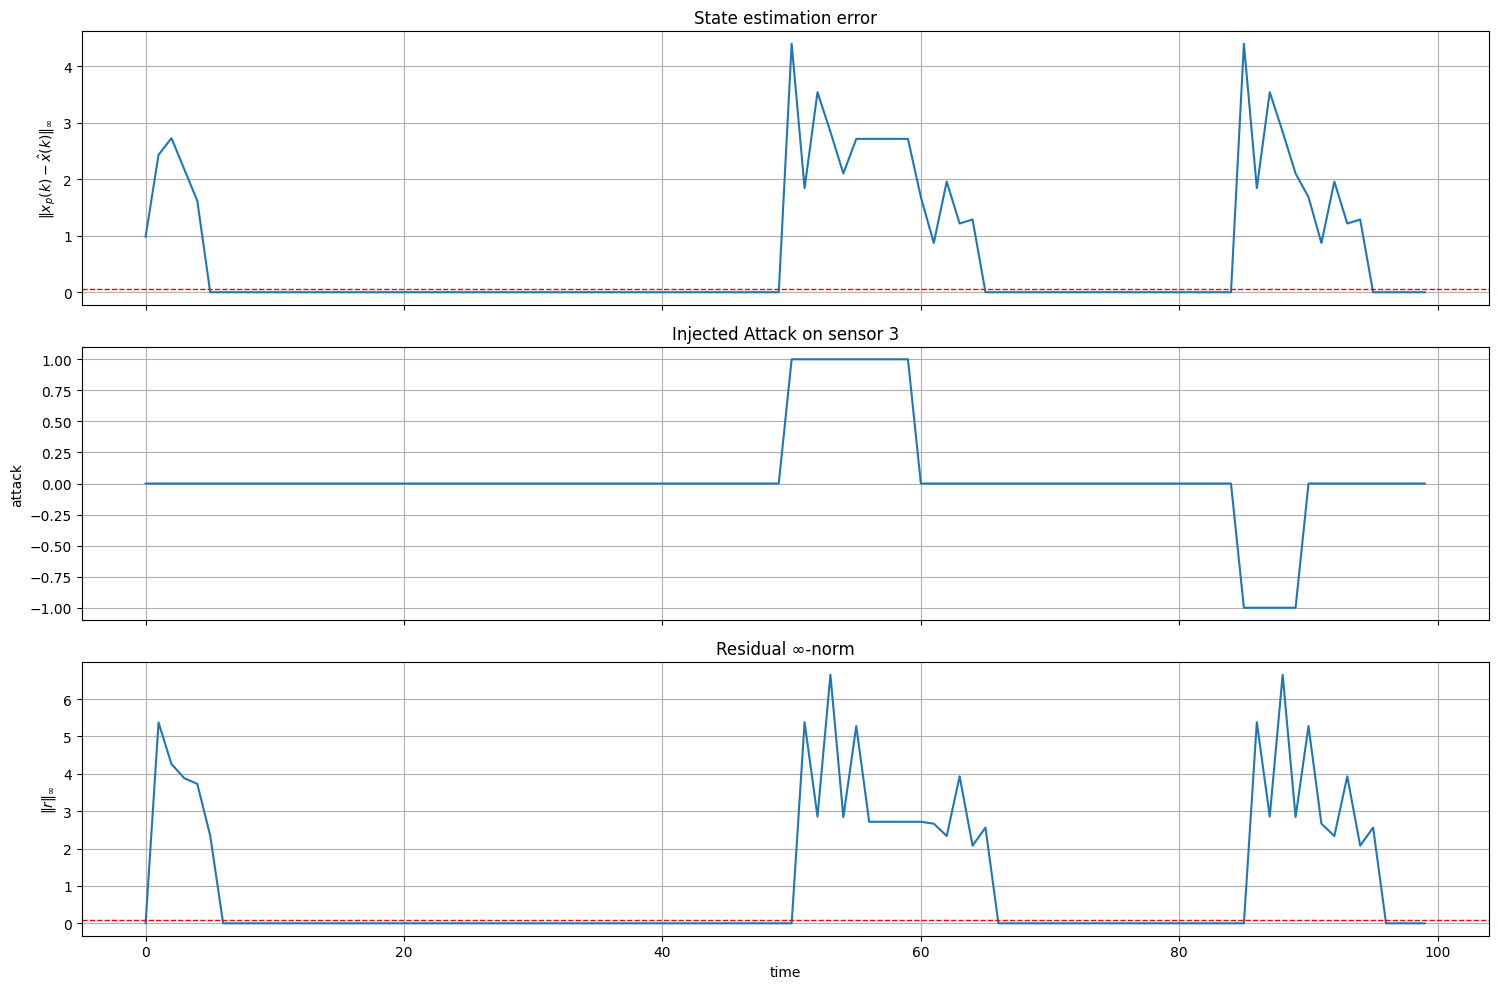

In [ ]:
'''
결과 플롯
'''
from matplot2tikz import save

# 시간축
t_x = np.arange(len(xp))        # 상태는 k=0..iter → 길이 iter+1
t_u = np.arange(len(u))         # u, y, residue는 k=0..iter-1 → 길이 iter

# 상태 xp: 리스트(각각 6x1)를 6x(iter+1)로 쌓기
xp_arr = np.hstack(xp)          # 6 x (iter+1)



# x_hat: 6 x iter
x_hat_arr = np.hstack(x_hat_list)  # 6 x iter


# 입력 u: (iter,)
u_arr = np.array(u)             # (iter,)

# 출력 y: 5x(iter)
y_arr = np.hstack(y)            # 5 x iter


# 플롯
# 상태 xp vs x_hat (6개)
t_k = np.arange(iter)  # 0..iter-1

e_arr = xp_arr[:,1:] - x_hat_arr[:,1:]
err_inf = np.max(np.abs(e_arr), axis=0)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# 1) state error ∞-norm
# axes[0].plot(t_k[7:], err_inf[7:],linestyle='-')
# axes[0].plot(t_k[7:], err_infq[7:],linestyle='--')
axes[0].plot(t_k, err_inf,linestyle='-')
axes[0].axhline(0.05, color='red', linestyle='--', linewidth=1)
axes[0].grid(True)
axes[0].set_ylabel(r"$\|x_p(k)-\hat{x}(k)\|_\infty$")
axes[0].set_title("State estimation error")

# 2) attack
axes[1].plot(t_u, attack_arr)
axes[1].grid(True)
axes[1].set_ylabel("attack")
axes[1].set_title("Injected Attack on sensor 3")

# 3) residual ∞-norm
r_inf = np.max(np.abs(residue), axis=1)
axes[2].plot(t_u, r_inf, label=r"$\|r\|_\infty$",linestyle='-')
# axes[2].plot(t_u[7:], r_inf[7:], label=r"$\|r\|_\infty$",linestyle='-')
axes[2].axhline(0.1, color='red', linestyle='--', linewidth=1)
axes[2].grid(True)
axes[2].set_xlabel("time")
axes[2].set_ylabel(r"$\|r\|_\infty$")
axes[2].set_title("Residual ∞-norm")

save("myplot.tex")
fig.tight_layout()
plt.show()






